**Note:** use T4 GPU runtime on colab

**Hardware Note: Why the NVIDIA T4 GPU?**

DL and quantum simulations rely heavily on parallel matrix operations.
* **Classical Baseline:** CNNs process thousands of pixel weights via convolution. A CPU processes these sequentially (which is severely bottlenecked). The T4 GPU utilizes thousands of CUDA cores to calculate these matrix multiplications in parallel. This drops epoch times from minutes to ~15 seconds.
* **Quantum Simulation:** Later in this project, we will use PennyLane to simulate quantum circuits. Calculating the tensor products of quantum state vectors scales exponentially. A GPU backend ensures that simulating these quantum states classically does not stall our training pipeline.

#### **Clone git repo and install requirements**

In [1]:
import os

#check if the repository folder already exists on the Colab disk
#(for if we've pushed new changes from remote repo to git and pull them on here)
if os.path.exists('/content/QML4EO-reproduction'):
    print("Repo found! Pulling latest changes from GitHub..")
    %cd /content/QML4EO-reproduction
    !git pull
else:
    print("Cloning repo for the first time..")
    %cd /content
    !git clone https://github.com/yeshapan/QML4EO-reproduction.git
    %cd QML4EO-reproduction

#install required dependencies
!pip install -r requirements.txt -q

Cloning repo for the first time..
/content
Cloning into 'QML4EO-reproduction'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 72 (delta 25), reused 60 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 6.81 MiB | 4.19 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/QML4EO-reproduction
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

#### **Test data loader (and confirm satellite images are loading correctly)**

Downloading/Loading EuroSAT dataset into ./data...


100%|██████████| 94.3M/94.3M [00:01<00:00, 59.9MB/s]


Dataset loaded successfully!
Total images: 27000 | Training: 21600 | Validation: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Batch Image Tensor Shape: torch.Size([32, 3, 64, 64])
Batch Label Tensor Shape: torch.Size([32])


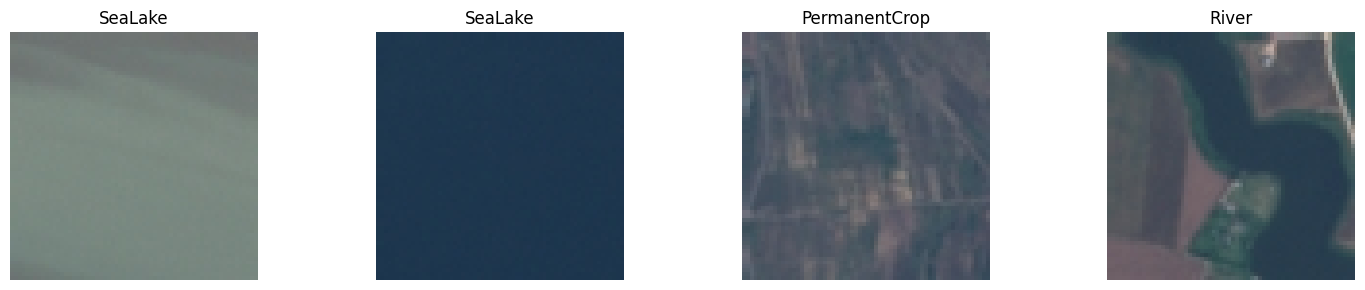

In [2]:
import matplotlib.pyplot as plt
import numpy as np

#import your custom data loader from the src/utils folder
from src.utils.data_loader import get_eurosat_dataloaders

#download and load the data
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=32,
    img_size=64
)

#grab exactly one batch of data to inspect it
images, labels = next(iter(train_loader))
print(f"\nBatch Image Tensor Shape: {images.shape}")
print(f"Batch Label Tensor Shape: {labels.shape}")

#let's visualize the first 4 images (to make sure they look right)
fig, axes = plt.subplots(1, 4, figsize=(15, 3))

#we have to reverse the mathematical normalization we did in data_loader.py so matplotlib can display the actual RGB colors correctly
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(4):
    #PyTorch uses (Channels, Height, Width) but Matplotlib needs (Height, Width, Channels)
    img = images[i].numpy().transpose((1, 2, 0))
    img = std * img + mean #un-normalize
    img = np.clip(img, 0, 1) #lock pixel values between 0 and 1

    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### **Establishing the Classical Benchmark (CNN)**

Now we establish our classical performance floor. We initialize a lightweight, resolution-agnostic PyTorch CNN and train it on the EuroSAT dataset.

To ensure empirical rigor, a single training run is not enough. Neural network initialization is inherently random. We wrap our training execution in a loop across 3 distinct random seeds for 15 epochs each. This accounts for weight variance and gives us a statistically sound baseline.

**The Goal:** Record the Total Trainable Parameters and the final Mean Validation Accuracy ($\pm$ Standard Deviation). This provides a benchmark to compare against our hybrid quantum models later.

In [4]:
import torch
import numpy as np
from src.utils.data_loader import get_eurosat_dataloaders
from src.baselines.cnn import ClassicalCNN, train_baseline, set_seed

#verify device and connect to the T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware utilized: {device}")

#re-initialize the dataloaders for a clean training run
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=32,
    img_size=64
)

#define rigorous test parameters
SEEDS = [42, 100, 2026]
EPOCHS = 15

#containers to hold metrics for statistical analysis
all_train_losses = []
all_val_accs = []

print("\nStarting Rigorous Classical Training:")

for seed in SEEDS:
    print(f"\n TRAINING SEED: {seed} ")

    #lock the randomness for this specific run
    set_seed(seed)

    #re-initialize the model so it starts fresh with weights dictated by the new seed
    model = ClassicalCNN(num_classes=len(classes))
    model = model.to(device)

    #execute the training loop
    history = train_baseline(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        lr=0.001,
        device=device
    )

    #save the full array of metrics for this seed
    all_train_losses.append(history['train_loss'])
    all_val_accs.append(history['val_acc'])

#convert lists to numpy arrays to easily calculate mean and standard deviation across seeds
acc_array = np.array(all_val_accs)
loss_array = np.array(all_train_losses)

mean_acc = np.mean(acc_array, axis=0)
std_acc = np.std(acc_array, axis=0)

#calculate and print total trainable parameters once
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters (Classical CNN): {total_params:,}")

#report the final rigorous metric
print(f"Final Classical Baseline: {mean_acc[-1]:.2f}% ± {std_acc[-1]:.2f}%")

Hardware utilized: cuda
Downloading/Loading EuroSAT dataset into ./data...
Dataset loaded successfully!
Total images: 27000 | Training: 21600 | Validation: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Starting Rigorous Classical Training:

 TRAINING SEED: 42 


Epoch 1/15 [Train]: 100%|██████████| 675/675 [00:15<00:00, 44.35it/s, loss=1.3107]


Epoch 1 Summary -> Train Loss: 1.6680 | Val Accuracy: 50.46%


Epoch 2/15 [Train]: 100%|██████████| 675/675 [00:14<00:00, 46.16it/s, loss=0.9490]


Epoch 2 Summary -> Train Loss: 1.2507 | Val Accuracy: 59.50%


...

Epoch 13 Summary -> Train Loss: 0.6054 | Val Accuracy: 79.87%


Epoch 14/15 [Train]: 100%|██████████| 675/675 [00:13<00:00, 51.72it/s, loss=0.5080]


Epoch 14 Summary -> Train Loss: 0.5977 | Val Accuracy: 77.00%


Epoch 15/15 [Train]: 100%|██████████| 675/675 [00:13<00:00, 50.97it/s, loss=0.5325]


Epoch 15 Summary -> Train Loss: 0.5890 | Val Accuracy: 79.57%

Total Trainable Parameters (Classical CNN): 5,418
Final Classical Baseline: 79.15% ± 0.63%


**Analysis**

Running 15 epochs across 3 seeds establishes a rigorous classical baseline.

1. **Statistical Stability:** The model reached a mean validation accuracy of 79.15% ± 0.63%. This tight variance proves our CNN is stable. It does not rely on a lucky weight initialization.
2. **Convergence Trajectory:** The model learns rapidly early on. It breaks 70% accuracy within 5 epochs. The learning curve flattens around Epoch 10. The 5418 parameters simply hit their representational limit.
3. **The Target:** This ~79% accuracy is our strict baseline. If our hybrid quantum models hit this mark, the PyTorch-PennyLane integration works. If they exceed it, we observe true quantum expressivity.

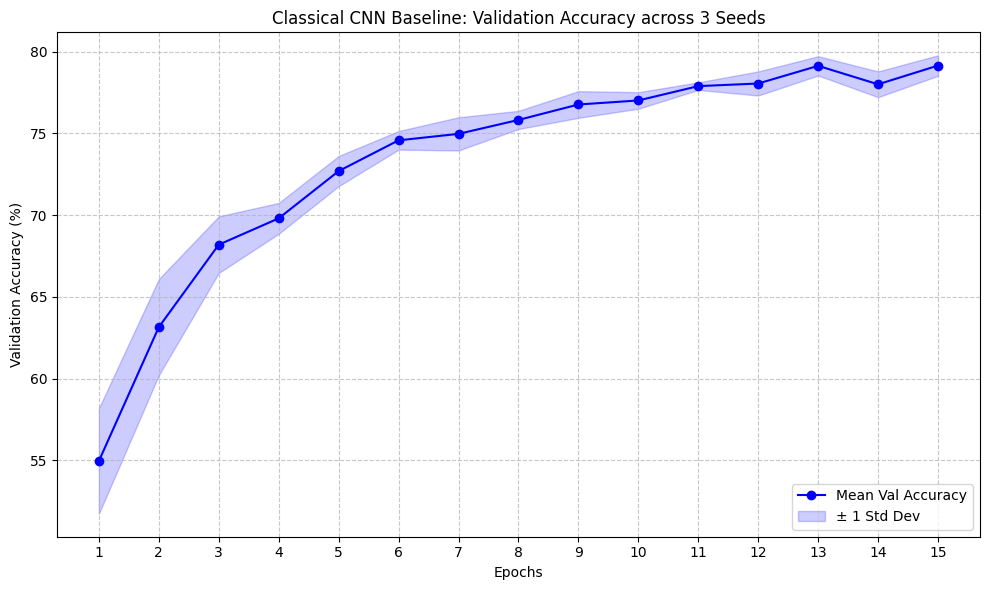

In [6]:
import matplotlib.pyplot as plt

#create an array of epoch numbers for the x-axis
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 6))

#plot the mean validation accuracy
plt.plot(epochs_range, mean_acc, label='Mean Val Accuracy', color='blue', marker='o')

#fill the area between (mean - std) and (mean + std) to show variance
plt.fill_between(
    epochs_range,
    mean_acc - std_acc,
    mean_acc + std_acc,
    color='blue',
    alpha=0.2,
    label='± 1 Std Dev'
)

plt.title('Classical CNN Baseline: Validation Accuracy across 3 Seeds')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.xticks(epochs_range)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()